# Model Robustness Under Distribution Shift
 

## 1. Imports

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 2. Rebuild Noisy Dataset

Since only the scaled CSVs were saved in the preprocessing step, we reconstruct the noisy (but unscaled) dataset here by re-applying the exact same `inject_climate_reality` function used in `00_preprocessing.ipynb`. Using the same random seed (`seed=42`) guarantees the noise injected here is identical to that used during preprocessing.

In [37]:
def inject_climate_reality(data, target_col="FloodProbability", seed=42):
    df_noisy = data.copy()
    np.random.seed(seed)

    # Feature Noise (real-world measurement error)
    high_noise = [
        "MonsoonIntensity",
        "Urbanization",
        "ClimateChange",
        "Siltation",
        "AgriculturalPractices",
        "IneffectiveDisasterPreparedness",
        "DrainageSystems",
        "Encroachments",
        "PopulationScore",
        "WetlandLoss",
        "InadequatePlanning",
        "PoliticalFactors",
    ]
    medium_noise = [
        "Deforestation",
        "DamsQuality",
        "DeterioratingInfrastructure",
        "RiverManagement",
        "Watersheds",
    ]
    low_noise = ["TopographyDrainage", "CoastalVulnerability", "Landslides"]

    for col in high_noise:
        df_noisy[col] += np.random.normal(0, 0.25, size=len(df_noisy))
    for col in medium_noise:
        df_noisy[col] += np.random.normal(0, 0.15, size=len(df_noisy))
    for col in low_noise:
        df_noisy[col] += np.random.normal(0, 0.05, size=len(df_noisy))

    # Clip features to valid ranges (0-10)
    feature_cols = high_noise + medium_noise + low_noise
    for col in feature_cols:
        df_noisy[col] = df_noisy[col].clip(lower=0)

    # Smooth Non-Linear Synergies
    synergy_1 = np.maximum(0, df_noisy["MonsoonIntensity"] - 7) * np.maximum(
        0, df_noisy["Deforestation"] - 7
    )
    df_noisy[target_col] += 0.01 * synergy_1

    synergy_2 = np.maximum(0, df_noisy["DeterioratingInfrastructure"] - 7) * np.maximum(
        0, df_noisy["PopulationScore"] - 7
    )
    df_noisy[target_col] += 0.008 * synergy_2

    # Heteroskedastic Target Noise
    base_noise = 0.05
    noise = np.random.normal(0, base_noise, size=len(df_noisy))
    df_noisy[target_col] += df_noisy[target_col] * 0.5 * noise

    # Clip target to valid range (0-1)
    df_noisy[target_col] = df_noisy[target_col].clip(0, 1)

    return df_noisy

In [38]:
# Load raw data and apply noise injection
df_raw = pd.read_csv("data/flood.csv")
df = inject_climate_reality(df_raw)

TARGET = "FloodProbability"
feature_cols = [c for c in df.columns if c != TARGET]

print(f"Dataset shape: {df.shape}")
print(f"FloodProbability mean: {df[TARGET].mean():.4f}")
print(f"FloodProbability std:  {df[TARGET].std():.4f}")

Dataset shape: (50000, 21)
FloodProbability mean: 0.5009
FloodProbability std:  0.0534


## 3. Define High-Risk and Low-Risk Subsets

We define the "high-risk" subset as observations where both `ClimateChange` and `Urbanization` exceed their 75th percentile. This reflects real-world scenarios where rapidly urbanizing regions under intensifying climate stress face the most severe and unpredictable flood conditions — precisely the environments where model reliability matters most.

The remaining samples form the "baseline" (lower-risk) subset, on which we train all three models.

In [39]:
threshold_cc = df["ClimateChange"].quantile(0.75)
threshold_ur = df["Urbanization"].quantile(0.75)

print(f"ClimateChange  75th percentile threshold : {threshold_cc:.4f}")
print(f"Urbanization   75th percentile threshold : {threshold_ur:.4f}")

high_risk_mask = (df["ClimateChange"] > threshold_cc) & (
    df["Urbanization"] > threshold_ur
)
low_risk_mask = ~high_risk_mask

df_baseline = df[low_risk_mask].reset_index(drop=True)
df_shifted = df[high_risk_mask].reset_index(drop=True)

print(
    f"\nBaseline (lower-risk) subset size : {len(df_baseline):,} ({len(df_baseline)/len(df)*100:.1f}%)"
)
print(
    f"Shifted  (higher-risk) subset size: {len(df_shifted):,} ({len(df_shifted)/len(df)*100:.1f}%)"
)
print(f"\nBaseline mean FloodProbability    : {df_baseline[TARGET].mean():.4f}")
print(f"Shifted  mean FloodProbability    : {df_shifted[TARGET].mean():.4f}")

ClimateChange  75th percentile threshold : 6.3103
Urbanization   75th percentile threshold : 6.3177

Baseline (lower-risk) subset size : 46,812 (93.6%)
Shifted  (higher-risk) subset size: 3,188 (6.4%)

Baseline mean FloodProbability    : 0.4989
Shifted  mean FloodProbability    : 0.5304


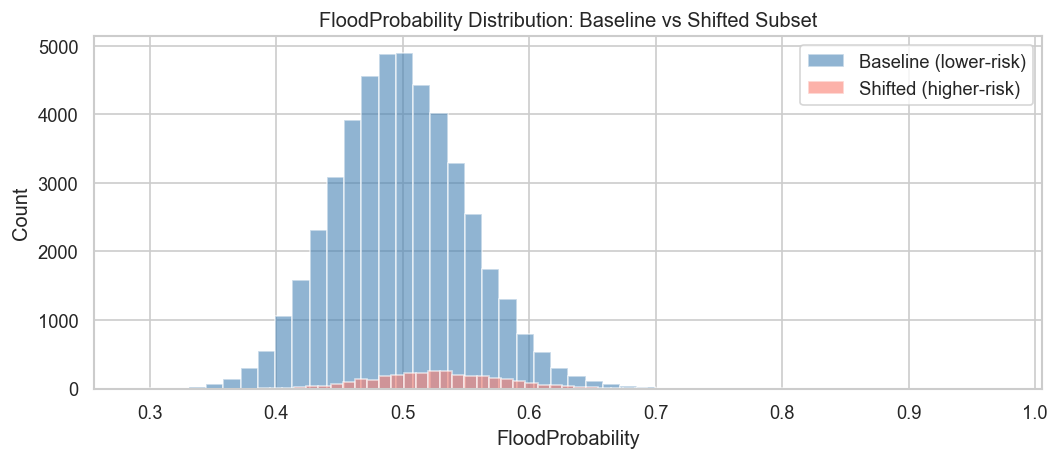

In [40]:
# Visualize FloodProbability distributions across subsets
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    df_baseline[TARGET],
    bins=50,
    alpha=0.6,
    color="steelblue",
    label="Baseline (lower-risk)",
    edgecolor="white",
)
ax.hist(
    df_shifted[TARGET],
    bins=50,
    alpha=0.6,
    color="salmon",
    label="Shifted (higher-risk)",
    edgecolor="white",
)
ax.set_xlabel("FloodProbability")
ax.set_ylabel("Count")
ax.set_title("FloodProbability Distribution: Baseline vs Shifted Subset")
ax.legend()
plt.tight_layout()
plt.show()

The high-risk subset is defined as observations where both ClimateChange and Urbanization exceed their respective 75th percentile thresholds (6.31 and 6.32). This results in a relatively small but meaningful shifted subset of 3,188 samples (6.4% of the full dataset), with the remaining 46,812 samples (93.6%) forming the baseline training set. As expected, the shifted subset shows a modestly higher mean FloodProbability (0.5304 vs 0.4989), which confirms that the high-risk conditions we selected do correspond to elevated flood risk. In the distribution plot, while both subsets overlap substantially in the 0.4–0.6 range, the shifted subset has a slightly right-skewed tail, showing the compounding effect of simultaneously elevated ClimateChange and Urbanization scores.

## 4. Feature Scaling

We fit the `StandardScaler` on the baseline (training) subset only. The same fitted scaler is then used to transform the shifted (test) subset. This mirrors real-world deployment conditions, where a model trained on historical lower-risk data is later applied to a higher-risk environment it has never seen.

In [41]:
X_train = df_baseline[feature_cols].copy()
y_train = df_baseline[TARGET].copy()

X_test = df_shifted[feature_cols].copy()
y_test = df_shifted[TARGET].copy()

# Fit scaler on baseline only — transform both
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print("Scaler fit on baseline subset only (no data leakage).")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled  shape : {X_test_scaled.shape}")

Scaler fit on baseline subset only (no data leakage).
X_train_scaled shape : (46812, 20)
X_test_scaled  shape : (3188, 20)


## 5. Evaluation Helpers

In [42]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


def evaluate(y_true, y_pred, model_name, split_name):
    return pd.DataFrame(
        {
            "Model": [model_name],
            "Split": [split_name],
            "R2": [round(r2_score(y_true, y_pred), 6)],
            "RMSE": [round(np.sqrt(mean_squared_error(y_true, y_pred)), 6)],
            "MAE": [round(mean_absolute_error(y_true, y_pred), 6)],
        }
    )


def residual_plots(y_true, y_pred, model_name, split_name):
    residuals = np.array(y_true) - np.array(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(y_pred, residuals, alpha=0.3, s=10, color="steelblue")
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Predicted FloodProbability")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title(f"{model_name} [{split_name}]: Residuals vs Fitted")

    axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"{model_name} [{split_name}]: Residual Distribution")

    plt.tight_layout()
    plt.show()


def stratified_error_table(X, y_true, y_pred, stratify_col, q=4):
    df_eval = X.copy()
    df_eval["actual"] = np.array(y_true)
    df_eval["pred"] = np.array(y_pred)
    df_eval["abs_error"] = np.abs(df_eval["actual"] - df_eval["pred"])
    df_eval["bin"] = pd.qcut(df_eval[stratify_col], q=q, duplicates="drop")

    out = (
        df_eval.groupby("bin", observed=False)
        .agg(
            n=("abs_error", "size"),
            mean_abs_error=("abs_error", "mean"),
            rmse=(
                "pred",
                lambda s: np.sqrt(np.mean((df_eval.loc[s.index, "actual"] - s) ** 2)),
            ),
        )
        .reset_index()
    )
    return out

## 6. Model 1: Multiple Linear Regression

We train the linear regression model on the baseline subset and evaluate it on both subsets to measure performance degradation under distribution shift.

Linear Regression — Baseline vs Shifted


,Model,Split,R2,RMSE,MAE
0,Linear Regression,Baseline (lower-risk),0.910411,0.015820,0.011467
1,Linear Regression,Shifted (higher-risk),0.891082,0.017312,0.012270


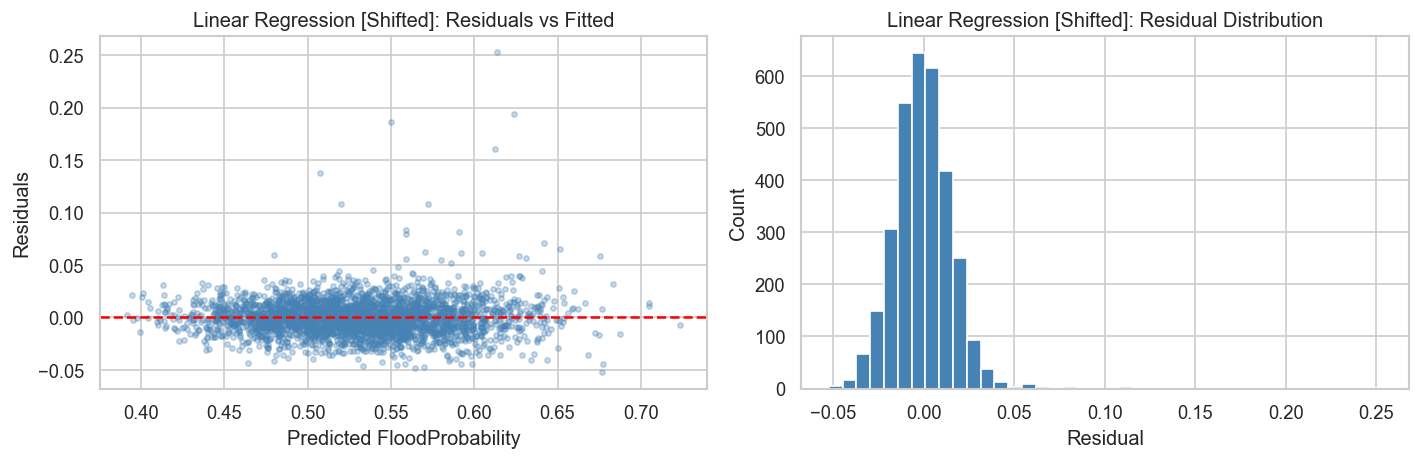

Linear Regression error by ClimateChange quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.709, 1.015]",797,0.012954,0.019085
1,"(1.015, 1.337]",797,0.011690,0.015482
2,"(1.337, 1.807]",797,0.011988,0.016591
3,"(1.807, 5.564]",797,0.012446,0.017880


Linear Regression error by Urbanization quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.71, 1.015]",797,0.012344,0.017397
1,"(1.015, 1.342]",797,0.011375,0.015319
2,"(1.342, 1.855]",797,0.013167,0.020144
3,"(1.855, 5.846]",797,0.012192,0.015992


In [43]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

lin_train_pred = lin_model.predict(X_train_scaled)
lin_shift_pred = lin_model.predict(X_test_scaled)

lin_base_result = evaluate(
    y_train, lin_train_pred, "Linear Regression", "Baseline (lower-risk)"
)
lin_shift_result = evaluate(
    y_test, lin_shift_pred, "Linear Regression", "Shifted (higher-risk)"
)

print("Linear Regression — Baseline vs Shifted")
display(pd.concat([lin_base_result, lin_shift_result], ignore_index=True))

residual_plots(y_test, lin_shift_pred, "Linear Regression", "Shifted")

print("Linear Regression error by ClimateChange quartile (Shifted subset):")
display(stratified_error_table(X_test_scaled, y_test, lin_shift_pred, "ClimateChange"))

print("Linear Regression error by Urbanization quartile (Shifted subset):")
display(stratified_error_table(X_test_scaled, y_test, lin_shift_pred, "Urbanization"))

Linear Regression proves to be the most robust model under distribution shift, with R² dropping only marginally from 0.9104 on the baseline to 0.8911 on the shifted subset — a degradation of just 0.0193. The RMSE increases slightly from 0.0158 to 0.0173, and MAE from 0.0115 to 0.0123, both remaining at very low levels. This stability is consistent with the model's architectural strengths: since the underlying data-generating process is fundamentally linear, the linear model generalizes well even when the input distribution shifts toward higher-risk conditions. The residual plot on the shifted subset shows no clear systematic pattern — residuals are centered around zero and remain tightly bounded within ±0.05 for the vast majority of predictions, with only a small number of outliers in the higher flood probability range. The residual distribution is approximately symmetric and concentrated near zero, further confirming that the model is not introducing directional bias when applied to the high-risk subset.

## 7. Model 2: XGBoost Regressor

XGBoost is trained on the same baseline subset using the same hyperparameters as in `01_modeling.ipynb` to ensure a fair comparison.

XGBoost — Baseline vs Shifted


,Model,Split,R2,RMSE,MAE
0,XGBoost,Baseline (lower-risk),0.896588,0.016996,0.013387
1,XGBoost,Shifted (higher-risk),0.759071,0.025748,0.020044


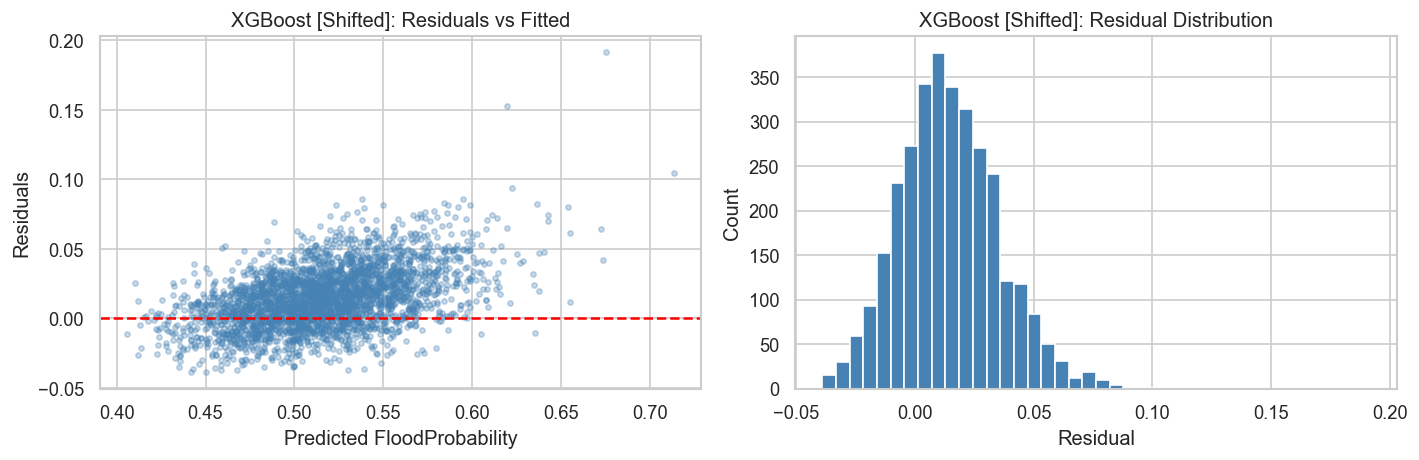

XGBoost error by ClimateChange quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.709, 1.015]",797,0.018517,0.024661
1,"(1.015, 1.337]",797,0.018050,0.022821
2,"(1.337, 1.807]",797,0.019464,0.024578
3,"(1.807, 5.564]",797,0.024143,0.030312


XGBoost error by Urbanization quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.71, 1.015]",797,0.016844,0.021513
1,"(1.015, 1.342]",797,0.017985,0.023120
2,"(1.342, 1.855]",797,0.020447,0.026852
3,"(1.855, 5.846]",797,0.024898,0.030553


In [44]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train_scaled, y_train)

xgb_train_pred = xgb_model.predict(X_train_scaled)
xgb_shift_pred = xgb_model.predict(X_test_scaled)

xgb_base_result = evaluate(y_train, xgb_train_pred, "XGBoost", "Baseline (lower-risk)")
xgb_shift_result = evaluate(y_test, xgb_shift_pred, "XGBoost", "Shifted (higher-risk)")

print("XGBoost — Baseline vs Shifted")
display(pd.concat([xgb_base_result, xgb_shift_result], ignore_index=True))

residual_plots(y_test, xgb_shift_pred, "XGBoost", "Shifted")

print("XGBoost error by ClimateChange quartile (Shifted subset):")
display(stratified_error_table(X_test_scaled, y_test, xgb_shift_pred, "ClimateChange"))

print("XGBoost error by Urbanization quartile (Shifted subset):")
display(stratified_error_table(X_test_scaled, y_test, xgb_shift_pred, "Urbanization"))

XGBoost shows a more pronounced performance drop under distribution shift compared to Linear Regression, with R² falling from 0.8966 on the baseline to 0.7591 on the shifted subset — a degradation of 0.1375. RMSE increases from 0.0170 to 0.0257 and MAE from 0.0134 to 0.0200, representing roughly a 50% increase in both error metrics. This is a meaningful deterioration, and it reflects a known limitation of tree-based ensemble models: they interpolate well within the training distribution but struggle to extrapolate to regions of the feature space that are underrepresented during training. Since the shifted subset consists of samples with simultaneously high ClimateChange and Urbanization，a combination that makes up only 6.4% of the full dataset. XGBoost has seen relatively few such examples and cannot generalize as effectively. The residual plot shows a noticeable positive skew, with residuals clustering slightly above zero across the predicted probability range, indicating that XGBoost tends to systematically underestimate flood probability in high-risk conditions.

## 8. Model 3: Sparse Optimal Decision Tree

The same grid search procedure from `01_modeling.ipynb` is re-run here on the baseline subset to select the best sparse tree under the shifted evaluation setting.

Best Sparse-Optimal Tree Params: {'ccp_alpha': np.float64(0.0), 'max_depth': 5, 'min_samples_leaf': 100}
Sparse Decision Tree — Baseline vs Shifted


,Model,Split,R2,RMSE,MAE
0,Sparse Decision Tree,Baseline (lower-risk),0.208982,0.047007,0.037372
1,Sparse Decision Tree,Shifted (higher-risk),-0.158331,0.056457,0.044478


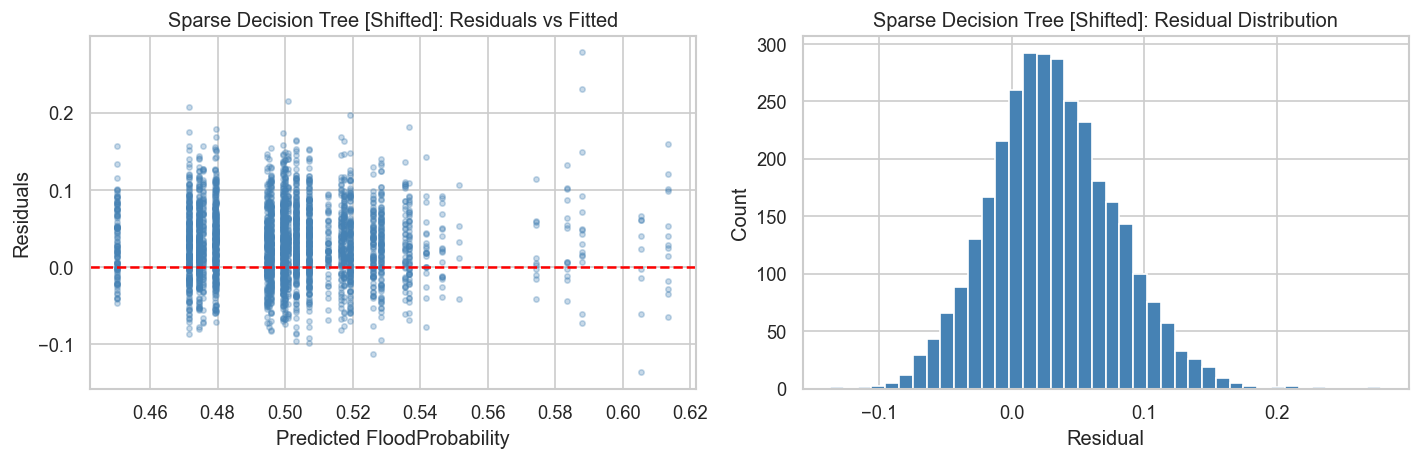

Sparse Decision Tree error by ClimateChange quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.709, 1.015]",797,0.041219,0.053438
1,"(1.015, 1.337]",797,0.041671,0.053226
2,"(1.337, 1.807]",797,0.043760,0.054954
3,"(1.807, 5.564]",797,0.051264,0.063569


Sparse Decision Tree error by Urbanization quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.71, 1.015]",797,0.039608,0.049705
1,"(1.015, 1.342]",797,0.042351,0.053917
2,"(1.342, 1.855]",797,0.044778,0.057927
3,"(1.855, 5.846]",797,0.051177,0.063374


In [45]:
base_tree = DecisionTreeRegressor(random_state=42)
path = base_tree.cost_complexity_pruning_path(X_train_scaled, y_train)
candidate_alphas = np.unique(np.round(path.ccp_alphas, 6))
candidate_alphas = candidate_alphas[candidate_alphas >= 0]

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [25, 50, 100],
    "ccp_alpha": candidate_alphas,
}

sot_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
sot_grid.fit(X_train_scaled, y_train)
tree_model = sot_grid.best_estimator_

print("Best Sparse-Optimal Tree Params:", sot_grid.best_params_)

tree_train_pred = tree_model.predict(X_train_scaled)
tree_shift_pred = tree_model.predict(X_test_scaled)

tree_base_result = evaluate(
    y_train, tree_train_pred, "Sparse Decision Tree", "Baseline (lower-risk)"
)
tree_shift_result = evaluate(
    y_test, tree_shift_pred, "Sparse Decision Tree", "Shifted (higher-risk)"
)

print("Sparse Decision Tree — Baseline vs Shifted")
display(pd.concat([tree_base_result, tree_shift_result], ignore_index=True))

residual_plots(y_test, tree_shift_pred, "Sparse Decision Tree", "Shifted")

print("Sparse Decision Tree error by ClimateChange quartile (Shifted subset):")
display(stratified_error_table(X_test_scaled, y_test, tree_shift_pred, "ClimateChange"))

print("Sparse Decision Tree error by Urbanization quartile (Shifted subset):")
display(stratified_error_table(X_test_scaled, y_test, tree_shift_pred, "Urbanization"))

The Sparse Optimal Decision Tree exhibits the most severe performance degradation of all three models, with R² collapsing from 0.2090 on the baseline to -0.1583 on the shifted subset — a total degradation of 0.3673. A negative R² means the model performs worse than simply predicting the mean of the target variable, which is a complete breakdown of predictive ability. RMSE and MAE also increase substantially, from 0.0470 to 0.0565 and from 0.0374 to 0.0445 respectively. This outcome is not surprising given the model's structural constraints — with a maximum depth of 5, the tree is limited to 32 leaf nodes and can only capture coarse, high-level decision boundaries. When applied to the shifted subset, where the feature combinations lie outside the regions most heavily represented in training, those coarse boundaries fail entirely. The residual plot makes this clear: predictions are concentrated in a narrow range of discrete values (visible as vertical stripes), and residuals are widely scattered with no centering around zero. The right-skewed residual distribution further confirms a systematic tendency to underestimate flood probability in high-risk scenarios.

## 9. Final Robustness Comparison
 

In [46]:
all_results = pd.concat(
    [
        lin_base_result,
        lin_shift_result,
        xgb_base_result,
        xgb_shift_result,
        tree_base_result,
        tree_shift_result,
    ],
    ignore_index=True,
)

print("Full Results Table")
display(all_results)

# Compute R² degradation per model
degradation_rows = []
for model_name in all_results["Model"].unique():
    subset = all_results[all_results["Model"] == model_name]
    r2_base = subset[subset["Split"].str.contains("lower")]["R2"].values[0]
    r2_shift = subset[subset["Split"].str.contains("higher")]["R2"].values[0]
    degradation_rows.append(
        {
            "Model": model_name,
            "Baseline R2": round(r2_base, 4),
            "Shifted R2": round(r2_shift, 4),
            "R2 Degradation": round(r2_base - r2_shift, 4),
        }
    )

degradation_df = pd.DataFrame(degradation_rows).sort_values(
    "R2 Degradation", ascending=False
)
print("\nR² Degradation under Distribution Shift")
display(degradation_df)

Full Results Table


,Model,Split,R2,RMSE,MAE
0,Linear Regression,Baseline (lower-risk),0.910411,0.015820,0.011467
1,Linear Regression,Shifted (higher-risk),0.891082,0.017312,0.012270
2,XGBoost,Baseline (lower-risk),0.896588,0.016996,0.013387
3,XGBoost,Shifted (higher-risk),0.759071,0.025748,0.020044
4,Sparse Decision Tree,Baseline (lower-risk),0.208982,0.047007,0.037372
5,Sparse Decision Tree,Shifted (higher-risk),-0.158331,0.056457,0.044478



R² Degradation under Distribution Shift


,Model,Baseline R2,Shifted R2,R2 Degradation
2,Sparse Decision Tree,0.2090,-0.1583,0.3673
1,XGBoost,0.8966,0.7591,0.1375
0,Linear Regression,0.9104,0.8911,0.0193


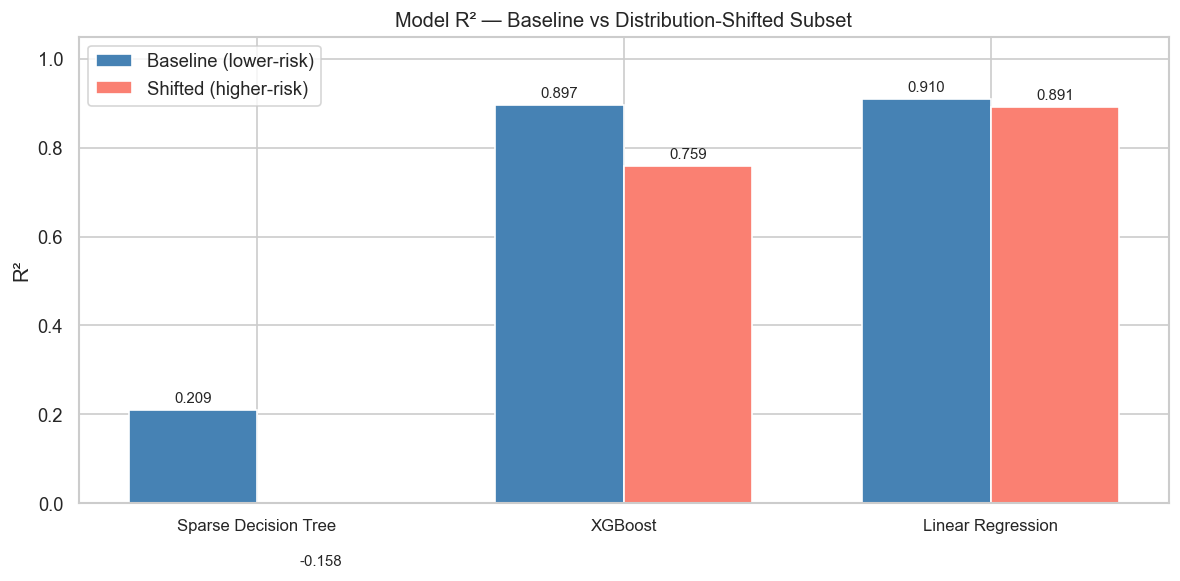

In [47]:
# Bar chart: Baseline vs Shifted R² per model
models = degradation_df["Model"].tolist()
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(
    x - width / 2,
    degradation_df["Baseline R2"],
    width,
    label="Baseline (lower-risk)",
    color="steelblue",
    edgecolor="white",
)
bars2 = ax.bar(
    x + width / 2,
    degradation_df["Shifted R2"],
    width,
    label="Shifted (higher-risk)",
    color="salmon",
    edgecolor="white",
)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel("R²")
ax.set_title("Model R² — Baseline vs Distribution-Shifted Subset")
ax.legend()
ax.set_ylim(0, 1.05)

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

Linear Regression is by far the most robust, with an R² degradation of only 0.0193. Its parametric, globally-fitted nature means that the linear relationships learned on the baseline subset transfer well to the high-risk conditions, where the same underlying feature relationships hold — just at higher values.

XGBoost falls in the middle, with a degradation of 0.1375. While it achieves strong baseline performance, its reliance on locally-fitted trees makes it more sensitive to distribution shift. The model has simply not seen enough high-risk examples during training to reliably generalize to the shifted subset.

The Sparse Decision Tree suffers the most, with a degradation of 0.3673 and a negative shifted R² of -0.1583. Its shallow depth and aggressive pruning, which were already limiting factors on the full dataset, become catastrophic under distribution shift — the model lacks both the resolution and the flexibility to adapt to the new input distribution.


## 10. Ethical Risk Discussion

The distribution shift analysis surfaces an important ethical concern: if our models perform systematically worse on the high-risk subset — precisely the regions characterized by high urbanization and intensifying climate stress — then the communities most vulnerable to flooding are also the ones receiving the least reliable predictions.

This pattern reflects a broader issue of infrastructural bias in predictive modeling. Areas with poor drainage systems, inadequate planning, and limited disaster preparedness tend to cluster in the high-risk subset. If a model trained predominantly on lower-risk conditions is deployed in these regions, it may:

- **Underestimate flood probability**, leading to insufficient preparation and resource allocation
- **Systematically disadvantage infrastructure-poor areas**, where decision-makers rely more heavily on predictive tools due to limited local capacity
- **Reinforce existing inequalities**, as prediction errors in high-risk regions translate directly to delayed emergency response and greater human and economic loss
 